<a href="https://colab.research.google.com/github/luccasnn/analise_sentimento/blob/main/analise_sentimento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')
nltk.download('stopwords')

# Dataset real de reviews da Amazon
url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nColunas:", df.columns.tolist())
print("\nPrimeiros registros:")
df.head()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Shape: (31962, 3)

Colunas: ['id', 'label', 'tweet']

Primeiros registros:


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [ ]:
print("Total de tweets:", len(df))
print("\nDistribuição do label:")
print(df['label'].value_counts())
print("\nExemplo de tweet:")
print(df['tweet'].iloc[0])

Total de tweets: 31962

Distribuição do label:
label
0    29720
1     2242
Name: count, dtype: int64

Exemplo de tweet:
 @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run


In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

# Aplica o VADER em cada tweet
df['scores'] = df['tweet'].apply(lambda x: sia.polarity_scores(str(x)))
df['compound'] = df['scores'].apply(lambda x: x['compound'])
df['sentimento'] = df['compound'].apply(
    lambda x: 'Positivo' if x >= 0.05 else ('Negativo' if x <= -0.05 else 'Neutro')
)

print("Distribuição de sentimentos detectados pelo VADER:")
print(df['sentimento'].value_counts())
df[['tweet', 'label', 'compound', 'sentimento']].head(10)

Distribuição de sentimentos detectados pelo VADER:
sentimento
Positivo    13270
Neutro      12729
Negativo     5963
Name: count, dtype: int64


,tweet,label,compound,sentimento
0,@user when a father is dysfunctional and is s...,0,-0.8296,Negativo
1,@user @user thanks for #lyft credit i can't us...,0,0.6705,Positivo
2,bihday your majesty,0,0.0000,Neutro
3,#model i love u take with u all the time in ...,0,0.7249,Positivo
4,factsguide: society now #motivation,0,0.0000,Neutro
5,[2/2] huge fan fare and big talking before the...,0,-0.4215,Negativo
6,@user camping tomorrow @user @user @user @use...,0,0.0000,Neutro
7,the next school year is the year for exams.ð...,0,0.0000,Neutro
8,we won!!! love the land!!! #allin #cavs #champ...,0,0.8770,Positivo
9,@user @user welcome here ! i'm it's so #gr...,0,0.5550,Positivo


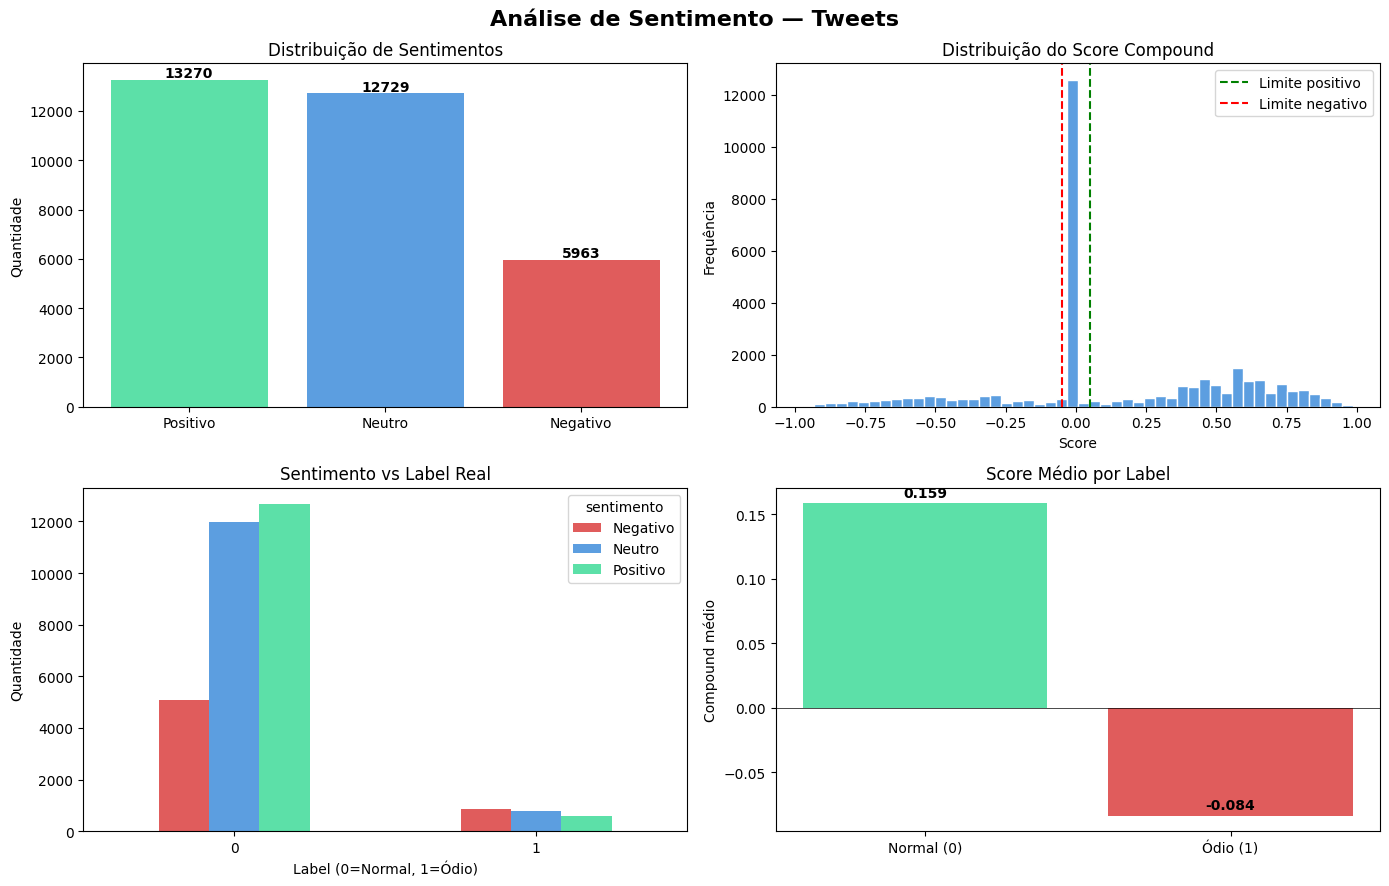

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Análise de Sentimento — Tweets', fontsize=16, fontweight='bold')

# 1. Distribuição de sentimentos
sentimento_counts = df['sentimento'].value_counts()
cores = {'Positivo': '#5ce0a8', 'Neutro': '#5c9ee0', 'Negativo': '#e05c5c'}
axes[0, 0].bar(sentimento_counts.index, sentimento_counts.values,
               color=[cores[s] for s in sentimento_counts.index])
axes[0, 0].set_title('Distribuição de Sentimentos')
axes[0, 0].set_ylabel('Quantidade')
for i, v in enumerate(sentimento_counts.values):
    axes[0, 0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# 2. Distribuição do score compound
axes[0, 1].hist(df['compound'], bins=50, color='#5c9ee0', edgecolor='white')
axes[0, 1].axvline(x=0.05, color='green', linestyle='--', label='Limite positivo')
axes[0, 1].axvline(x=-0.05, color='red', linestyle='--', label='Limite negativo')
axes[0, 1].set_title('Distribuição do Score Compound')
axes[0, 1].set_xlabel('Score')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].legend()

# 3. Sentimento vs Label real
import numpy as np
label_sentimento = df.groupby(['label', 'sentimento']).size().unstack(fill_value=0)
label_sentimento.plot(kind='bar', ax=axes[1, 0],
                      color=[cores[c] for c in label_sentimento.columns])
axes[1, 0].set_title('Sentimento vs Label Real')
axes[1, 0].set_xlabel('Label (0=Normal, 1=Ódio)')
axes[1, 0].set_ylabel('Quantidade')
axes[1, 0].tick_params(axis='x', rotation=0)

# 4. Score médio por label
score_medio = df.groupby('label')['compound'].mean()
axes[1, 1].bar(['Normal (0)', 'Ódio (1)'], score_medio.values,
               color=['#5ce0a8', '#e05c5c'])
axes[1, 1].set_title('Score Médio por Label')
axes[1, 1].set_ylabel('Compound médio')
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
for i, v in enumerate(score_medio.values):
    axes[1, 1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('sentimento_analise.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import files


files.download('sentimento_analise.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>